<a href="https://colab.research.google.com/github/yawarabbasmalik/Airlines-Arrival-Delay-Analysis/blob/main/Traffic_Sign_Recognition.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Importing Required Libraries and Setting Paths

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from keras.layers import Conv2D, Dense, Flatten, MaxPool2D, Dropout
import random
from matplotlib.image import imread
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import warnings

## Setting Constants and Paths

In [ ]:
# Set the data directory paths

input_data = 'C:/Users/HP/GTSRB - German Traffic Sign Recognition Benchmark'
train_data = 'C:/Users/HP/GTSRB - German Traffic Sign Recognition Benchmark/Train'
test_data = 'C:/Users/HP/GTSRB - German Traffic Sign Recognition Benchmark'

## Image Parameters and Categories

In [ ]:
# Resizing the images to 30x30x3

image_ht = 30
image_wd = 30
channels = 3

## Counting the Number of Categories

In [ ]:
# Determine the number of categories (classes)

total_categories = len(os.listdir(train_data))
total_categories

43

## Target Class Overview

In [ ]:
# Define the class labels

classes = {
    0: '20 KM/Hr Speed Limit', 1: '30 KM/Hr Speed Limit', 2: '50 KM/Hr Speed Limit', 3: '60 KM/Hr Speed Limit', 4: '70 KM/Hr Speed Limit',
    5: '80 KM/Hr Speed Limit', 6: '80 KM/Hr Speed Limit End', 7: '100 KM/Hr Speed Limit', 8: '120 KM/Hr Speed Limit', 9: 'No Vehicle Passing Allowed',
    10: 'No Vehicle Passing Allowed > 3.5 Tons', 11: 'Right-of-way at Intersection', 12: 'Priority Road', 13: 'Yield', 14: 'Stop',
    15: 'Vehicles are not Allowed', 16: 'Vehilce > 3.5 Tons are Prohibited', 17: 'No Entry', 18: 'General Caution', 19: 'On Left Dangerous Curve',
    20: 'On Right Dangerous Curve', 21: 'Double Curve', 22: 'Bumpy Road', 23: 'Slippery Road', 24: 'Right Side, Road Narrows',
    25: 'Working on Road', 26: 'Traffic Signals', 27: 'Pedestrians', 28: 'Children Crossing', 29: 'Bicycles Crossing', 30: 'Beware of Ice/Snow',
    31: 'Crossing of Wild Animals', 32: 'Passing Limits + End Speed', 33: 'Right Turning Ahead', 34: 'Left Turning Ahead', 35: 'Ahead Only',
    36: 'Move Right or Straight', 37: 'Move Left or Straight', 38: 'Keep on Right', 39: 'Keep on Left', 40: 'Mandatory RoundAbout',
    41: 'No Passing, Ends', 42: 'Vehicle > 3.5 Tons No Passing, Ends'
}

## Data Exploration - Number of Images per Class

In [ ]:
# Get the list of folders (classes) in the train directory

folders = os.listdir(train_data)


In [ ]:
# Calculate the number of training images in each class and create a list of class labels

train_number = []
class_num = []

for folder in folders:
    train_files = os.listdir(train_data + '/' + folder)
    train_number.append(len(train_files))
    class_num.append(classes[int(folder)])

In [ ]:
# Sorting the dataset on the basis of the number of images in each class
zipped_lists = zip(train_number, class_num)
sorted_pairs = sorted(zipped_lists)
tuples = zip(*sorted_pairs)
train_number, class_num = [ list(tuple) for tuple in  tuples]

## Plotting the Number of Images per Class

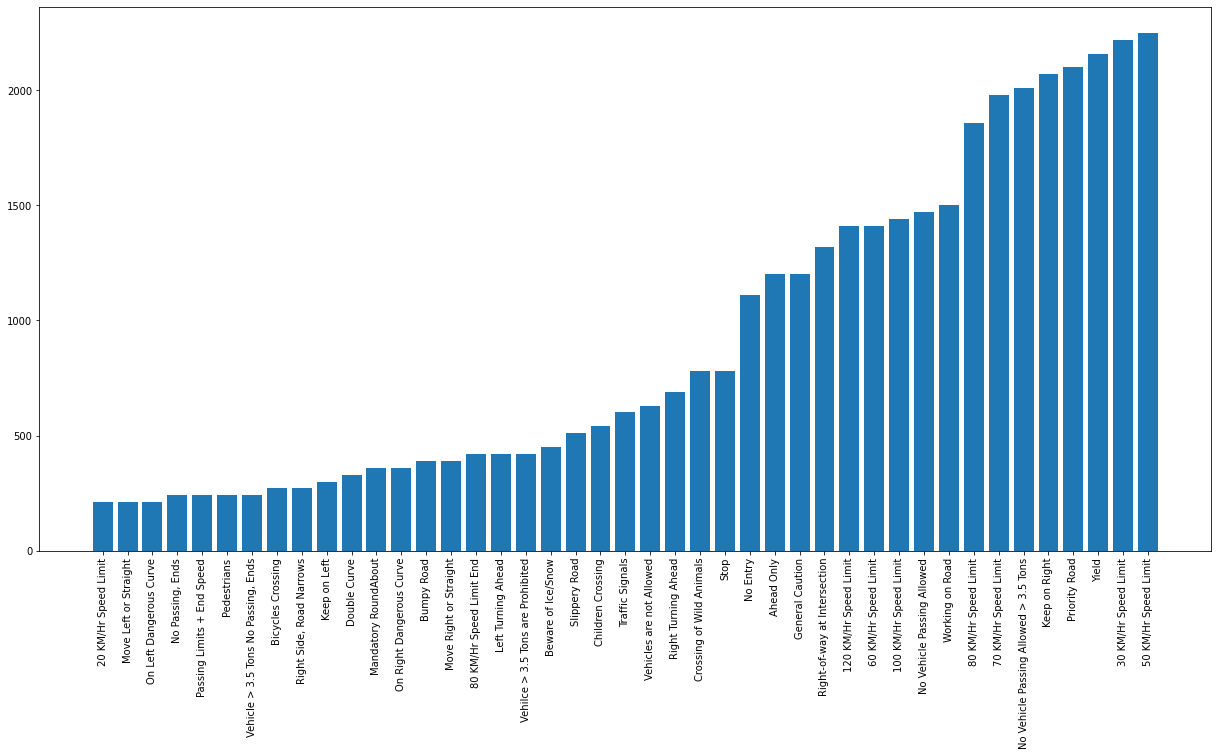

In [ ]:
# Plotting the number of images in each class
plt.figure(figsize=(21,10))
plt.bar(class_num, train_number)
plt.xticks(class_num, rotation='vertical')
plt.show()

## Visualizing Random Images from Test Data

C:\Users\HP\AppData\Local\Temp/ipykernel_12772/1958122832.py:15: MatplotlibDeprecationWarning: The 'b' parameter of grid() has been renamed 'visible' since Matplotlib 3.5; support for the old name will be dropped two minor releases later.
  plt.grid(b=None)


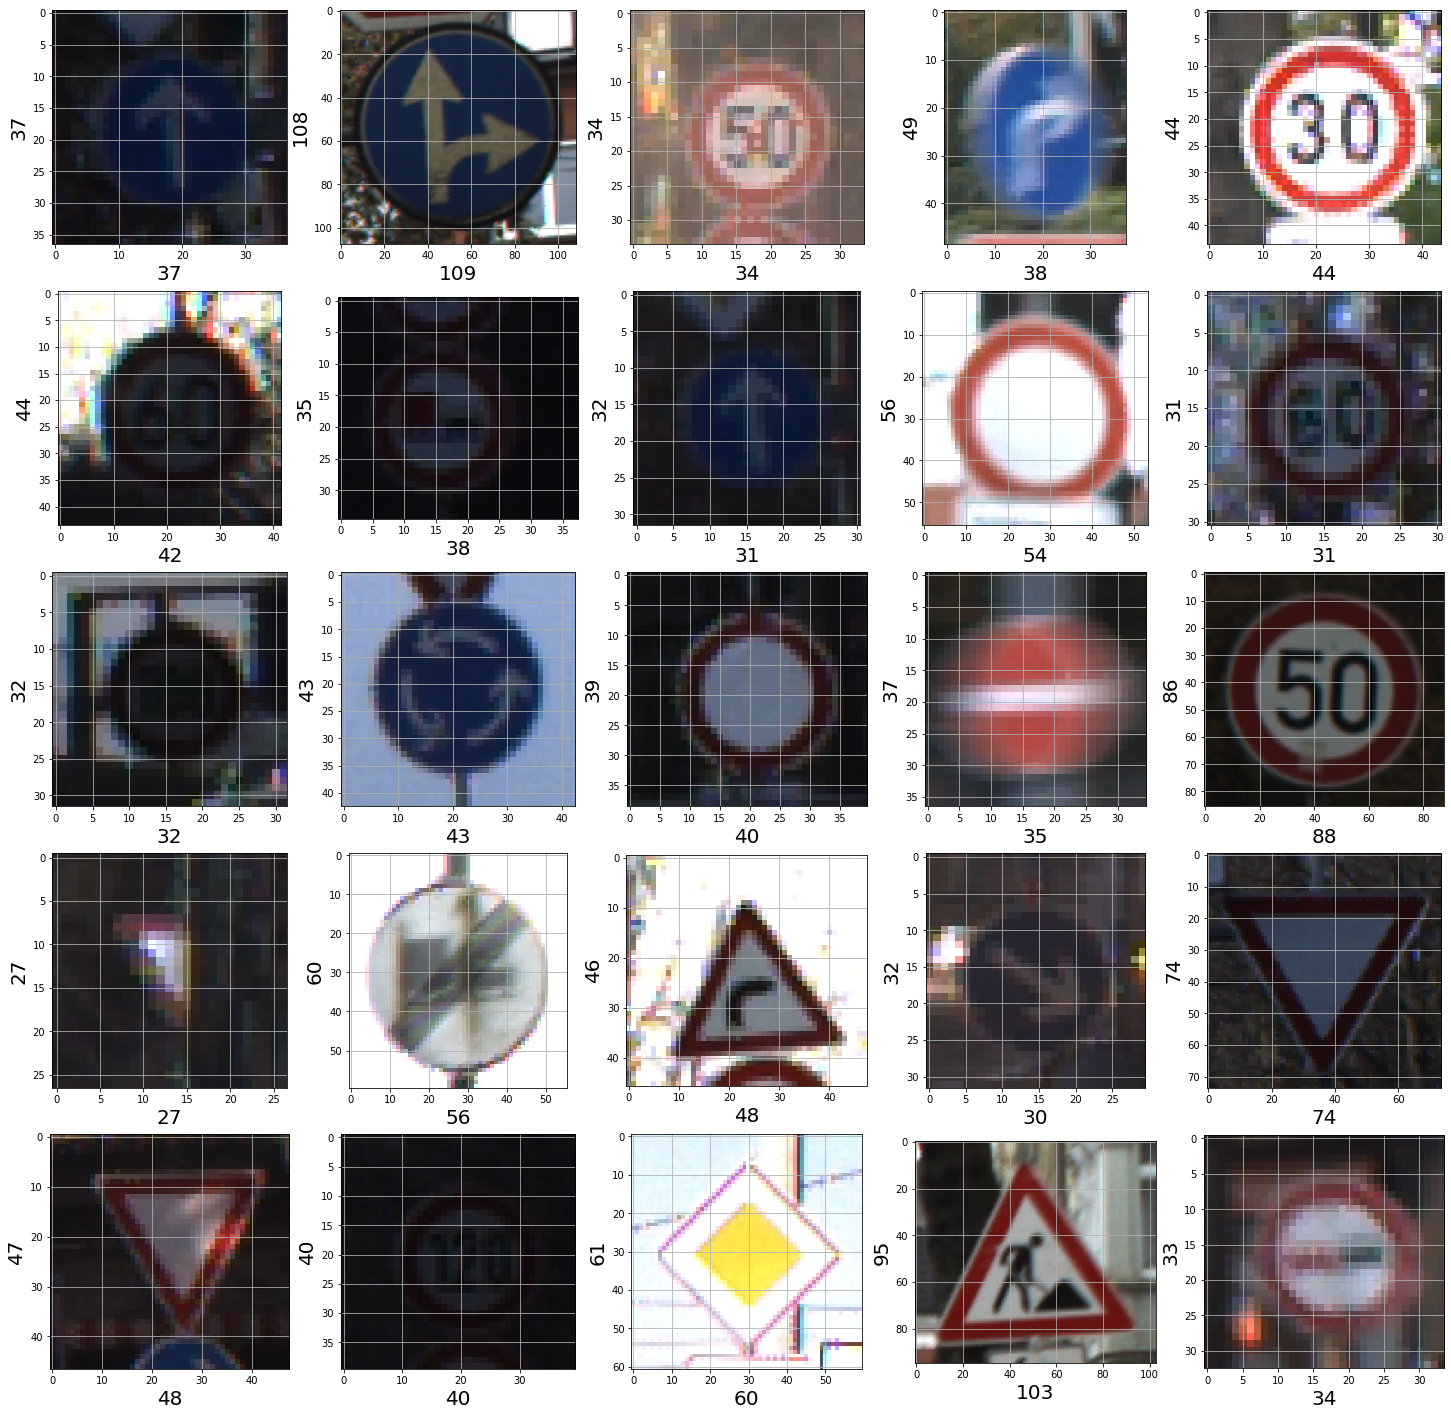

In [ ]:
# Visualizing 25 random images from the test data

# Read the test dataset CSV file

test = pd.read_csv(input_data + '/Test.csv')
imgs = test["Path"].values

plt.figure(figsize=(25,25))

for i in range(1,26):
    plt.subplot(5,5,i)
    random_img_path = input_data + '/' + random.choice(imgs)
    rand_img = imread(random_img_path)
    plt.imshow(rand_img)
    plt.grid(b=None)
    plt.xlabel(rand_img.shape[1], fontsize = 20) # Image Width
    plt.ylabel(rand_img.shape[0], fontsize = 20) # Image Height

## Loading and Preparing the Training Data

In [ ]:
# Prepare the training data

# Set the image directory pat

imgs_path = 'C:/Users/HP/GTSRB - German Traffic Sign Recognition Benchmark/Train'
data_list = []
labels_list = []
classes_list = 43

In [ ]:
# Iterate over each class folder and resize the images

for i in range(classes_list):
    i_path = os.path.join(imgs_path, str(i)) #0-42
    for img in os.listdir(i_path):
        im = Image.open(i_path +'/'+ img)
        im = im.resize((30,30))
        im = np.array(im)
        data_list.append(im)
        labels_list.append(i)

In [ ]:
# Convert the data and labels into NumPy arrays

data = np.array(data_list)
labels = np.array(labels_list)
print("Images resizing is performed successfully")

Images resizing is performed successfully


## Loading and Preparing the Test Data

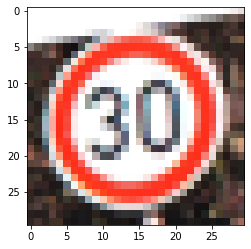

In [ ]:
# Visualize a sample image

path = "C:/Users/HP/GTSRB - German Traffic Sign Recognition Benchmark/Train/1/00001_00006_00028.png"
img = Image.open(path)
img = img.resize((30, 30))
sr = np.array(img)
plt.imshow(img)
plt.show()

## Splitting the Data into Training and Testing Sets

In [ ]:
# Split the data into training and testing sets

x_train, x_test, y_train, y_test= train_test_split(data, labels, test_size= 0.1, random_state=10)

print("training_shape: ", x_train.shape,y_train.shape)
print("testing_shape: ", x_test.shape,y_test.shape)

training_shape:  (35288, 30, 30, 3) (35288,)
testing_shape:  (3921, 30, 30, 3) (3921,)


## One-Hot Encoding the Labels

In [ ]:
# Convert the labels to one-hot encoding

y_train = tf.one_hot(y_train,43)
y_test = tf.one_hot(y_test,43)

## Creating the CNN Model

In [ ]:
# Define the model architecture

model = tf.keras.Sequential()

model.add(Conv2D(filters=32, kernel_size=(5,5), activation="relu", input_shape= x_train.shape[1:]))
model.add((Conv2D(filters=64, kernel_size=(5,5), activation="relu")))
model.add(MaxPool2D(pool_size=(2,2)))
model.add(Dropout(rate=0.25))
model.add((Conv2D(filters=128,kernel_size=(3,3),activation="relu")))
model.add((MaxPool2D(pool_size=(2,2))))
model.add(Dropout(rate=0.25))
model.add(Flatten())
model.add(Dense(1024, activation="relu"))
model.add(Dropout(rate=0.40))
model.add(Dense(43, activation="softmax"))

In [ ]:
# Print the model summary

model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 26, 26, 32)        2432      
                                                                 
 conv2d_1 (Conv2D)           (None, 22, 22, 64)        51264     
                                                                 
 max_pooling2d (MaxPooling2D  (None, 11, 11, 64)       0         
 )                                                               
                                                                 
 dropout (Dropout)           (None, 11, 11, 64)        0         
                                                                 
 conv2d_2 (Conv2D)           (None, 9, 9, 128)         73856     
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 4, 4, 128)        0         
 2D)                                                    

## Compiling and Training the Model

In [ ]:
# Compile the model

model.compile(loss="categorical_crossentropy", optimizer="adam", metrics=["accuracy"])

In [ ]:
# Train the model

epochs = 10
history = model.fit(x_train, y_train, epochs=epochs, batch_size=64, validation_data=(x_test, y_test))

Epoch 1/10
552/552 [==============================] - 97s 173ms/step - loss: 1.2889 - accuracy: 0.7384 - val_loss: 0.1169 - val_accuracy: 0.9770
Epoch 2/10
552/552 [==============================] - 100s 181ms/step - loss: 0.2150 - accuracy: 0.9438 - val_loss: 0.0417 - val_accuracy: 0.9903
Epoch 3/10
552/552 [==============================] - 89s 162ms/step - loss: 0.1652 - accuracy: 0.9581 - val_loss: 0.0361 - val_accuracy: 0.9908
Epoch 4/10
552/552 [==============================] - 92s 166ms/step - loss: 0.1251 - accuracy: 0.9674 - val_loss: 0.0294 - val_accuracy: 0.9903
Epoch 5/10
552/552 [==============================] - 93s 168ms/step - loss: 0.1392 - accuracy: 0.9649 - val_loss: 0.0350 - val_accuracy: 0.9901
Epoch 6/10
552/552 [==============================] - 96s 173ms/step - loss: 0.1184 - accuracy: 0.9702 - val_loss: 0.0584 - val_accuracy: 0.9839
Epoch 7/10
552/552 [==============================] - 101s 182ms/step - loss: 0.1273 - accuracy: 0.9697 - val_loss: 0.0224 - val_

## Plotting Accuracy and Loss Curves

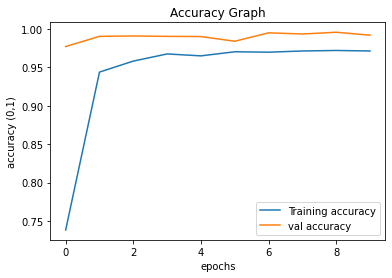

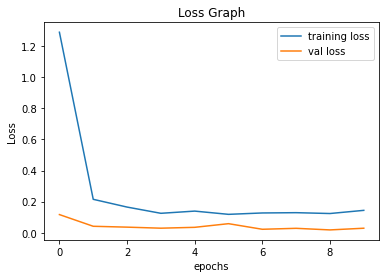

In [ ]:
# Plot the accuracy and loss graphs

plt.figure(0)
plt.plot(history.history['accuracy'], label="Training accuracy")
plt.plot(history.history['val_accuracy'], label="val accuracy")
plt.title("Accuracy Graph")
plt.xlabel("epochs")
plt.ylabel("accuracy (0,1)")
plt.legend()

plt.figure(1)
plt.plot(history.history['loss'], label="training loss")
plt.plot(history.history['val_loss'], label="val loss")
plt.title("Loss Graph")
plt.xlabel("epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()


## Evaluating Model Accuracy on Test Data

In [ ]:
# Evaluate the model on the test data

# Read the test dataset CSV file

test = pd.read_csv("C:/Users/HP/GTSRB - German Traffic Sign Recognition Benchmark/Test.csv")
test_labels = test['ClassId'].values
test_img_path = 'C:/Users/HP/GTSRB - German Traffic Sign Recognition Benchmark'
test_imgs = test['Path'].values

test_data = []
test_labels = []

In [ ]:
# Resize and preprocess the test images

for img in test_imgs:
    im = Image.open(test_img_path + '/' + img)
    im = im.resize((30,30))
    im = np.array(im)
    test_data.append(im)

test_data = np.array(test_data)
print(test_data.shape)

warnings.filterwarnings("ignore")

(12630, 30, 30, 3)


In [ ]:
# Make predictions on the test data

test_labels = test['ClassId'].values
test_labels

array([16,  1, 38, ...,  6,  7, 10], dtype=int64)

In [ ]:
# Calculate and print the accuracy score

predictions = np.argmax(model.predict(test_data),axis=1)
print("accuracy: ", accuracy_score(test_labels, predictions))

395/395 [==============================] - 9s 23ms/step
accuracy:  0.9589865399841647
